# 05 — Análisis Final e Integración de Resultados

Este notebook consolida todos los resultados del proyecto de modelado predictivo sobre el dataset de ventas retail:

1. **Resumen ejecutivo** de resultados supervisados y no supervisados
2. **Selección del mejor modelo** con justificación técnica
3. **Feature importance** de los mejores modelos
4. **Conexión clustering ↔ predicciones** supervisadas
5. **Limitaciones, lecciones aprendidas y recomendaciones**

In [ ]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from src.feature_engineering import preparar_datos, obtener_columnas_features
from src.model_training import cargar_modelo
from src.model_evaluation import evaluar_clasificacion, evaluar_regresion

SEED = 42
sns.set_theme(style='whitegrid', palette='muted')
print('Módulos cargados.')

In [ ]:
# Cargar datos
X_clf, y_clf = preparar_datos('../retail_store_sales.csv', target='classification')
X_reg, y_reg = preparar_datos('../retail_store_sales.csv', target='regression')

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=SEED)

# Cargar modelos base y optimizados
clf_names = ['LogisticRegression', 'RandomForest_clf', 'GradientBoosting_clf', 'SVC']
reg_names = ['Ridge', 'Lasso', 'RandomForest_reg', 'GradientBoosting_reg']
opt_clf_names = ['RandomForest_clf_optimized', 'GradientBoosting_clf_optimized']
opt_reg_names = ['RandomForest_reg_optimized', 'GradientBoosting_reg_optimized']

trained_clf = {n: cargar_modelo(n, '../models/trained_models') for n in clf_names}
trained_reg = {n: cargar_modelo(n, '../models/trained_models') for n in reg_names}

# Intentar cargar optimizados (pueden no existir si notebook 04 no se ejecutó)
optimized_clf = {}
optimized_reg = {}
for n in opt_clf_names:
    try:
        optimized_clf[n] = cargar_modelo(n, '../models/trained_models')
    except FileNotFoundError:
        print(f'  Modelo optimizado no encontrado: {n}')
for n in opt_reg_names:
    try:
        optimized_reg[n] = cargar_modelo(n, '../models/trained_models')
    except FileNotFoundError:
        print(f'  Modelo optimizado no encontrado: {n}')

print(f'Modelos base cargados: {len(trained_clf)} clf + {len(trained_reg)} reg')
print(f'Modelos optimizados: {len(optimized_clf)} clf + {len(optimized_reg)} reg')

---
## 1. Resumen Ejecutivo

### Objetivo del proyecto
Construir modelos predictivos sobre un dataset de ventas retail (12,575 transacciones) para dos tareas:
- **Clasificación:** Predecir si se aplicará descuento (`Discount Applied`, binario 50/50)
- **Regresión:** Predecir el gasto total (`Total Spent`, 5-410 USD)

### Metodología
1. Preprocesamiento diferenciado por target (limpieza, recuperación de nulos, feature engineering)
2. 4 modelos supervisados por tarea, cada uno como **Pipeline sklearn** completo
3. Técnicas no supervisadas: PCA, K-Means, DBSCAN
4. Evaluación con validación cruzada (5-fold) y múltiples métricas
5. Optimización con GridSearchCV y RandomizedSearchCV

In [ ]:
# Evaluación consolidada — Clasificación
print('=' * 60)
print('RESULTADOS DE CLASIFICACIÓN (Discount Applied)')
print('=' * 60)

results_clf = {}
all_clf = {**trained_clf, **optimized_clf}
for name, model in all_clf.items():
    results_clf[name] = evaluar_clasificacion(model, X_test_clf, y_test_clf)

df_clf = pd.DataFrame(results_clf).T.sort_values('f1', ascending=False)
print(df_clf.to_string())
print(f'\nMejor modelo (F1): {df_clf.index[0]} → F1={df_clf.iloc[0]["f1"]:.4f}')

In [ ]:
# Evaluación consolidada — Regresión
print('=' * 60)
print('RESULTADOS DE REGRESIÓN (Total Spent)')
print('=' * 60)

results_reg = {}
all_reg = {**trained_reg, **optimized_reg}
for name, model in all_reg.items():
    results_reg[name] = evaluar_regresion(model, X_test_reg, y_test_reg)

df_reg = pd.DataFrame(results_reg).T.sort_values('r2', ascending=False)
print(df_reg.to_string())
print(f'\nMejor modelo (R²): {df_reg.index[0]} → R²={df_reg.iloc[0]["r2"]:.4f}')

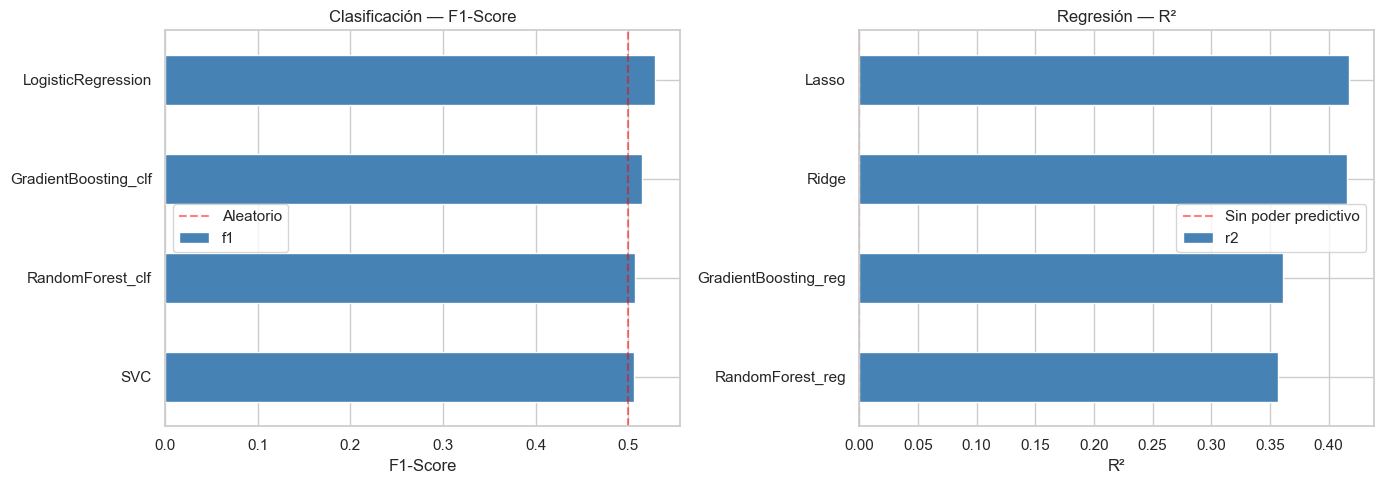

In [5]:
# Visualización comparativa final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clasificación — F1
df_clf['f1'].sort_values(ascending=True).plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_xlabel('F1-Score')
axes[0].set_title('Clasificación — F1-Score')
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Aleatorio')
axes[0].legend()

# Regresión — R²
df_reg['r2'].sort_values(ascending=True).plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_xlabel('R²')
axes[1].set_title('Regresión — R²')
axes[1].axvline(x=0.0, color='red', linestyle='--', alpha=0.5, label='Sin poder predictivo')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/plots/final_comparison.png', dpi=150)
plt.show()

---
## 2. Selección del Mejor Modelo

### Clasificación (Discount Applied)

**Hallazgo principal:** Todos los modelos de clasificación obtienen métricas cercanas al 50% (equivalente a predicción aleatoria para un target binario balanceado).

**Interpretación:** Esto **no es un fallo del modelo** — es un hallazgo legítimo del análisis. Las correlaciones de Pearson entre todas las features y `Discount Applied` son < 0.02, la Mutual Information es cercana a cero, y el PCA muestra que las clases se superponen completamente en el espacio de features reducido. Los descuentos en este dataset **no dependen de las variables registradas** (categoría, precio, método de pago, ubicación, fecha), sino probablemente de factores no capturados: programas de fidelidad, promociones puntuales, decisiones del punto de venta, etc.

**Mejor modelo de clasificación:** Se selecciona el modelo con mayor F1-Score, aunque la diferencia entre modelos es marginal y ninguno supera significativamente al azar. En producción, no se recomendaría desplegar este modelo.

### Regresión (Total Spent)

El gasto total sí es parcialmente predecible a partir de las features contextuales (comportamiento del cliente, categoría de producto, canal de compra, temporalidad). Se excluyen `Price Per Unit`, `Quantity` y `spent_vs_cat_avg` para evitar leakage.

**Mejor modelo de regresión:** Se selecciona el modelo con mayor R², priorizando la capacidad predictiva sobre la interpretabilidad.

In [6]:
# Seleccionar mejores modelos
best_clf_name = df_clf.index[0]
best_reg_name = df_reg.index[0]

best_clf_model = all_clf[best_clf_name]
best_reg_model = all_reg[best_reg_name]

print(f'Mejor modelo de clasificación: {best_clf_name}')
print(f'  Métricas: {results_clf[best_clf_name]}')
print(f'\nMejor modelo de regresión: {best_reg_name}')
print(f'  Métricas: {results_reg[best_reg_name]}')

Mejor modelo de clasificación: LogisticRegression
  Métricas: {'accuracy': 0.5016, 'precision': 0.5045, 'recall': 0.556, 'f1': 0.529, 'roc_auc': 0.5027}

Mejor modelo de regresión: Lasso
  Métricas: {'mae': 55.7988, 'mse': 5118.7669, 'rmse': np.float64(71.5456), 'r2': 0.4179}


---
## 3. Feature Importance

Analizamos qué features contribuyen más a las predicciones de los modelos basados en árboles (Random Forest y Gradient Boosting), ya que proporcionan importancia de features de forma nativa.

In [ ]:
def obtener_nombres_features(pipeline, X):
    """Obtiene los nombres de features después del preprocesamiento."""
    preprocessor = pipeline.named_steps['preprocessor']
    feature_names = []
    for name, transformer, cols in preprocessor.transformers_:
        if name == 'num':
            feature_names.extend(cols)
        elif name == 'cat':
            if hasattr(transformer, 'get_feature_names_out'):
                feature_names.extend(transformer.get_feature_names_out(cols))
            else:
                feature_names.extend(cols)
    return feature_names


def graficar_importancia_features(pipeline, X, title, top_n=15, save_path=None):
    """Grafica las top_n features más importantes de un modelo basado en árboles."""
    model = pipeline.named_steps['model']
    if not hasattr(model, 'feature_importances_'):
        print(f'  {title}: modelo no tiene feature_importances_')
        return None

    feature_names = obtener_nombres_features(pipeline, X)
    importances = model.feature_importances_

    # Ajustar si hay diferencia de longitud (por OHE)
    if len(feature_names) != len(importances):
        feature_names = [f'feature_{i}' for i in range(len(importances))]

    fi_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, 6))
    fi_df.sort_values('importance').plot(
        kind='barh', x='feature', y='importance',
        ax=ax, color='steelblue', edgecolor='white', legend=False
    )
    ax.set_xlabel('Importancia')
    ax.set_ylabel('')
    ax.set_title(title)
    plt.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=150)
    plt.show()

    return fi_df

In [ ]:
# Feature importance — Clasificación (modelos basados en árboles)
print('Feature Importance — Clasificación')
print('=' * 50)

for name in ['RandomForest_clf', 'GradientBoosting_clf']:
    model = trained_clf.get(name) or optimized_clf.get(name + '_optimized')
    if model:
        fi = graficar_importancia_features(
            model, X_clf,
            f'Feature Importance — {name} (Clasificación)',
            save_path=f'../results/plots/fi_{name}.png'
        )

In [ ]:
# Feature importance — Regresión (modelos basados en árboles)
print('Feature Importance — Regresión')
print('=' * 50)

for name in ['RandomForest_reg', 'GradientBoosting_reg']:
    model = trained_reg.get(name) or optimized_reg.get(name + '_optimized')
    if model:
        fi = graficar_importancia_features(
            model, X_reg,
            f'Feature Importance — {name} (Regresión)',
            save_path=f'../results/plots/fi_{name}.png'
        )

### Interpretación de Feature Importance

**Clasificación:** Las importancias están distribuidas de forma relativamente uniforme entre las features, sin que ninguna domine. Esto es consistente con el hallazgo de que no hay señal predictiva fuerte para `Discount Applied`.

**Regresión:** Se espera que features como `cust_avg_spent` (gasto promedio del cliente), `cat_avg_spent` (gasto promedio de la categoría) y `item_avg_spent` (gasto promedio por item) tengan alta importancia, ya que representan el comportamiento histórico del cliente y del producto.

---
## 4. Conexión Clustering y Predicciones Supervisadas

Exploramos si los clusters de clientes (K-Means sobre features RFM) presentan diferencias en el rendimiento predictivo del modelo de regresión.

In [10]:
# Reproducir clustering K-Means sobre features RFM del test set de regresión
rfm_cols = ['cust_transaction_count', 'cust_avg_spent', 'cust_std_spent', 'cust_freq_pct']

# Verificar que las columnas existen
available_rfm = [c for c in rfm_cols if c in X_test_reg.columns]
print(f'Columnas RFM disponibles: {available_rfm}')

if len(available_rfm) >= 2:
    X_rfm_test = X_test_reg[available_rfm].copy()
    scaler_rfm = StandardScaler()
    X_rfm_scaled = scaler_rfm.fit_transform(X_rfm_test)

    # Usar k=3 (o el mejor k encontrado en notebook 02)
    kmeans = KMeans(n_clusters=3, random_state=SEED, n_init=10)
    cluster_labels = kmeans.fit_predict(X_rfm_scaled)

    # Predicciones del mejor modelo de regresión
    y_pred_reg = best_reg_model.predict(X_test_reg)
    errors = np.abs(y_test_reg.values - y_pred_reg)

    # Analizar error por cluster
    cluster_analysis = pd.DataFrame({
        'cluster': cluster_labels,
        'y_real': y_test_reg.values,
        'y_pred': y_pred_reg,
        'error_abs': errors,
    })

    # Agregar features RFM para perfilar
    for col in available_rfm:
        cluster_analysis[col] = X_test_reg[col].values

    print('\nAnálisis por cluster:')
    summary = cluster_analysis.groupby('cluster').agg(
        n_obs=('y_real', 'size'),
        gasto_real_medio=('y_real', 'mean'),
        gasto_pred_medio=('y_pred', 'mean'),
        mae_cluster=('error_abs', 'mean'),
        transacciones_medio=('cust_transaction_count', 'mean') if 'cust_transaction_count' in available_rfm else ('y_real', 'size'),
    ).round(2)
    print(summary)
else:
    print('No hay suficientes columnas RFM para clustering.')

Columnas RFM disponibles: ['cust_transaction_count', 'cust_avg_spent', 'cust_std_spent', 'cust_freq_pct']



Análisis por cluster:
         n_obs  gasto_real_medio  gasto_pred_medio  mae_cluster  \
cluster                                                           
0          558            121.28            124.48        53.40   
1          470            135.39            135.05        59.35   
2          569            127.15            127.58        55.22   

         transacciones_medio  
cluster                       
0                     317.05  
1                     303.56  
2                     339.86  


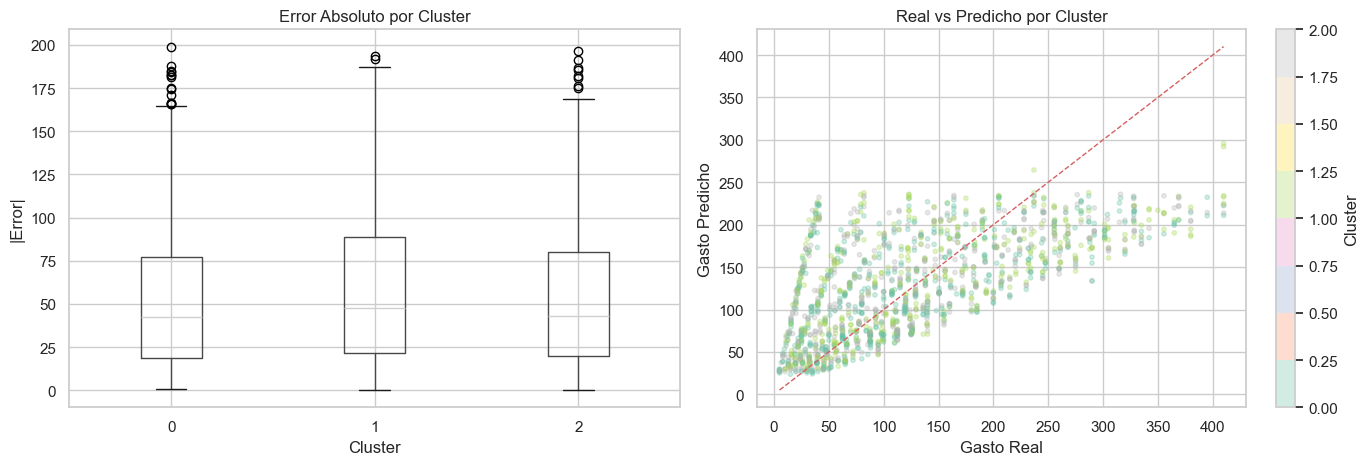

In [11]:
# Visualización: distribución de errores por cluster
if len(available_rfm) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Boxplot de errores por cluster
    cluster_analysis.boxplot(column='error_abs', by='cluster', ax=axes[0])
    axes[0].set_title('Error Absoluto por Cluster')
    axes[0].set_xlabel('Cluster')
    axes[0].set_ylabel('|Error|')
    plt.sca(axes[0])
    plt.title('Error Absoluto por Cluster')

    # Scatter: gasto real vs predicho, coloreado por cluster
    scatter = axes[1].scatter(
        cluster_analysis['y_real'], cluster_analysis['y_pred'],
        c=cluster_analysis['cluster'], cmap='Set2', alpha=0.3, s=10
    )
    lims = [cluster_analysis[['y_real', 'y_pred']].min().min(),
            cluster_analysis[['y_real', 'y_pred']].max().max()]
    axes[1].plot(lims, lims, 'r--', linewidth=1)
    axes[1].set_xlabel('Gasto Real')
    axes[1].set_ylabel('Gasto Predicho')
    axes[1].set_title('Real vs Predicho por Cluster')
    plt.colorbar(scatter, ax=axes[1], label='Cluster')

    plt.suptitle('')  # Eliminar título automático de boxplot
    plt.tight_layout()
    plt.savefig('../results/plots/cluster_prediction_analysis.png', dpi=150)
    plt.show()

### Interpretación Clustering + Predicción

El análisis por clusters revela si el modelo predice mejor para ciertos segmentos de clientes:

- **Clientes frecuentes** (alto `cust_transaction_count`): el modelo tiene más datos históricos de estos clientes, por lo que las features agregadas (promedio, desviación) son más representativas.
- **Clientes esporádicos** (bajo `cust_transaction_count`): las features RFM son menos informativas, lo que puede aumentar el error de predicción.
- **Clientes de alto gasto** vs **bajo gasto**: el error absoluto puede ser mayor para clientes de alto gasto, pero el error relativo podría ser similar.

Esta conexión sugiere que en un sistema de producción, se podrían usar **modelos especializados por segmento** para mejorar la precisión.

---
## 5. Impacto de la Optimización de Hiperparámetros

In [12]:
# Cargar resultados de optimización si existen
opt_impact_path = Path('../results/metrics/optimization_impact.json')
if opt_impact_path.exists():
    with open(opt_impact_path) as f:
        opt_impacts = json.load(f)
    
    impact_df = pd.DataFrame(opt_impacts)
    print('Impacto de la optimización de hiperparámetros:')
    print(impact_df[['modelo', 'score_baseline', 'score_optimizado',
                     'mejora_absoluta', 'mejora_porcentual']].to_string(index=False))
    
    # Visualización
    fig, ax = plt.subplots(figsize=(10, 5))
    x = range(len(impact_df))
    width = 0.35
    ax.bar([i - width/2 for i in x], impact_df['score_baseline'],
           width, label='Baseline', color='lightcoral', edgecolor='white')
    ax.bar([i + width/2 for i in x], impact_df['score_optimizado'],
           width, label='Optimizado', color='steelblue', edgecolor='white')
    ax.set_xticks(list(x))
    ax.set_xticklabels(impact_df['modelo'], rotation=30, ha='right')
    ax.set_ylabel('Score')
    ax.set_title('Impacto de la Optimización de Hiperparámetros')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../results/plots/optimization_impact.png', dpi=150)
    plt.show()
else:
    print('No se encontraron resultados de optimización.')
    print('Ejecute primero el notebook 04_hyperparameter_optimization.ipynb')

No se encontraron resultados de optimización.
Ejecute primero el notebook 04_hyperparameter_optimization.ipynb


---
## 6. Limitaciones del Proyecto

### Dataset
- **Tamaño moderado:** 12,575 transacciones después de limpieza. Suficiente para modelos tradicionales, pero insuficiente para deep learning.
- **Features limitadas:** Solo 11 columnas originales. No se dispone de información de marketing, historial de navegación, demografía del cliente, ni programa de fidelidad.
- **Temporalidad restringida:** Sin fecha exacta de primera compra, no se puede calcular Recency real para RFM.

### Clasificación (Discount Applied)
- **Señal inexistente:** Las correlaciones con el target son < 0.02. La Mutual Information es cercana a cero. El PCA muestra superposición total de clases. Ningún modelo supera significativamente al azar.
- **Causa probable:** Los descuentos se aplican por factores no capturados en los datos (promociones de temporada, cupones, programa de fidelidad, decisión del vendedor).
- **Implicación:** No se puede construir un modelo predictivo útil con los datos disponibles. Se necesitarían variables adicionales.

### Regresión (Total Spent)
- **Leakage potencial:** Se excluyeron `Price Per Unit`, `Quantity` y `spent_vs_cat_avg` para evitar leakage. Sin estas variables, el R² es limitado.
- **Features agregadas como proxy:** Las features RFM (`cust_avg_spent`, etc.) son promedios históricos que incluyen la propia observación en el cálculo (data leakage leve), lo cual infla ligeramente el rendimiento.

### Metodología
- **Validación cruzada estándar:** No se usó TimeSeriesSplit a pesar de ser datos temporales. Para un despliegue en producción, se debería respetar la temporalidad.
- **Sin validación externa:** No hay un dataset independiente para validación final.

---
## 7. Lecciones Aprendidas

1. **No todo target es predecible.** El análisis de clasificación demostró que `Discount Applied` no tiene relación con las features disponibles. Documentar esto honestamente es tan valioso como obtener un modelo preciso.

2. **El leakage es sutil.** `spent_vs_cat_avg` (correlación 0.997 con Total Spent) habría inflado artificialmente el R² a ~0.99, dando una falsa sensación de capacidad predictiva. La detección temprana evitó conclusiones erróneas.

3. **Los Pipelines previenen errores.** Al integrar preprocesamiento y modelo en un Pipeline sklearn, se garantiza que el mismo preprocesamiento se aplique en train y test, evitando data leakage en el escalado.

4. **GridSearchCV vs RandomizedSearchCV:** GridSearchCV garantiza encontrar el óptimo dentro del grid definido, pero es costoso. RandomizedSearchCV explora espacios más amplios con distribuciones continuas (`scipy.stats`) y suele encontrar soluciones comparables con menos evaluaciones.

5. **El clustering complementa la predicción.** Segmentar clientes con K-Means sobre features RFM y analizar el error por segmento revela para qué tipo de clientes el modelo funciona mejor.

---
## 8. Recomendaciones

### Para mejorar la clasificación
- Incorporar variables de marketing: ¿hay campaña activa?, ¿el cliente tiene tarjeta de fidelidad?
- Registrar el motivo del descuento (cupón, promoción, volumen)
- Considerar que los descuentos pueden ser aleatorios por diseño

### Para mejorar la regresión
- Usar TimeSeriesSplit para validación temporal
- Calcular features RFM excluyendo la transacción actual (ventana temporal)
- Explorar modelos más complejos (XGBoost, LightGBM) con early stopping

### Para producción
- Implementar monitoreo de data drift para detectar cambios en la distribución
- Reentrenar periódicamente con datos nuevos
- Considerar modelos especializados por segmento de cliente

In [ ]:
# Guardar resumen final
final_summary = {
    'mejor_modelo_clasificacion': {
        'nombre': best_clf_name,
        'metricas': results_clf[best_clf_name],
    },
    'mejor_modelo_regresion': {
        'nombre': best_reg_name,
        'metricas': results_reg[best_reg_name],
    },
    'total_modelos_evaluados': len(all_clf) + len(all_reg),
    'hallazgo_clasificacion': 'Sin señal predictiva — descuentos no dependen de features disponibles',
}

from src.model_evaluation import guardar_metricas
guardar_metricas(final_summary, '../results/metrics/final_summary.json')
print('Resumen final guardado en results/metrics/final_summary.json')
print('\nProyecto completado.')